In [33]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [34]:
import platform, matplotlib as mpl
from matplotlib.font_manager import FontProperties, findfont

def first_ok(cands):
    for name in cands:
        try:
            findfont(FontProperties(family=name), fallback_to_default=False)
            return name
        except Exception:
            pass
    return None

sys = platform.system()
if sys == "Darwin":   # macOS
    cjk_candidates = ["Songti SC", "Hiragino Sans GB", "STHeiti", "PingFang SC",   ]
elif sys == "Windows":
    cjk_candidates = ["Microsoft YaHei", "SimHei", "NSimSun", "KaiTi"]
else:                 # Linux
    cjk_candidates = ["Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Micro Hei", "AR PL UMing CN"]

cjk = first_ok(cjk_candidates)

#（可选）清理字体缓存，改完配置后建议重启 kernel
# import shutil; shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

mpl.rcParams.update({
    # 关键顺序：STIX（英文/数学） → DejaVu Sans（含 U+2212） → 中文
    "font.family": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),
    "font.sans-serif": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),

    # 数学字体固定用 STIX，防止落到“default”
    "mathtext.fontset": "stix",
    "mathtext.rm": "STIXGeneral",
    "mathtext.it": "STIXGeneral:italic",
    "mathtext.bf": "STIXGeneral:bold",

    "axes.unicode_minus": True,   # 使用 Unicode '−'（由 STIX/DejaVu 提供）
    "text.usetex": False,         # 没有配置 CJK 的 LaTeX 时必须关闭
    'font.size': 16, 
})
#print("CJK fallback:", cjk or "未找到；建议安装 Noto Sans CJK / 思源黑体 / 微软雅黑 / 苹方")

##====== 放大显示的字体
from IPython.display import HTML
HTML("""
<style>
/* —— JupyterLab 渲染后的 Markdown —— */
.jp-MarkdownCell .jp-RenderedHTMLCommon {
  font-size: 1.20em;          /* 整体放大 20% */
  line-height: 1.6;
}

/* 可选：调大标题层级（按需调） */
.jp-MarkdownCell h1 { font-size: 1.9em; }
.jp-MarkdownCell h2 { font-size: 1.6em; }
.jp-MarkdownCell h3 { font-size: 1.35em; }

/* 可选：渲染公式（MathJax v3）一起放大 */
.mjx-container { font-size: 115% !important; }
</style>
""")

## 课堂练习

1. 将下面的两组数据用进行插值
```python
x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
y = [1, 3, 2, 5, 4, 2, 3, 5, 4, 6]
```
在区间 [0, 9] 上生成 400 个均匀点 `x`
绘制：
- 原始散点（黑色点）
- 三次样条插值曲线 cs(xx)（红色）
- 图像必须加网格、图例、标题。

2. 对比三次样条与线性插值
```python
x = [0,1,2,3,4,5,6,7,8,9,10,11]
y = [2,3,5,4,6,7,5,4,6,8,7,9]
```
- 构造三次样条插值器
- 构造线性插值器：
  ```python
  lin = interp1d(x, y, kind='linear')
  ```
在 [0, 11] 上生成 500 个点，
在同一张图中绘制：
- 原始散点（黑色）
- cs(xx)（蓝色）
- lin(xx)（橙色）
- 写一句简单观察：“三次样条比线性插值更平滑” 或 “线性插值折线感更明显”
图像必须加网格、图例、标题。

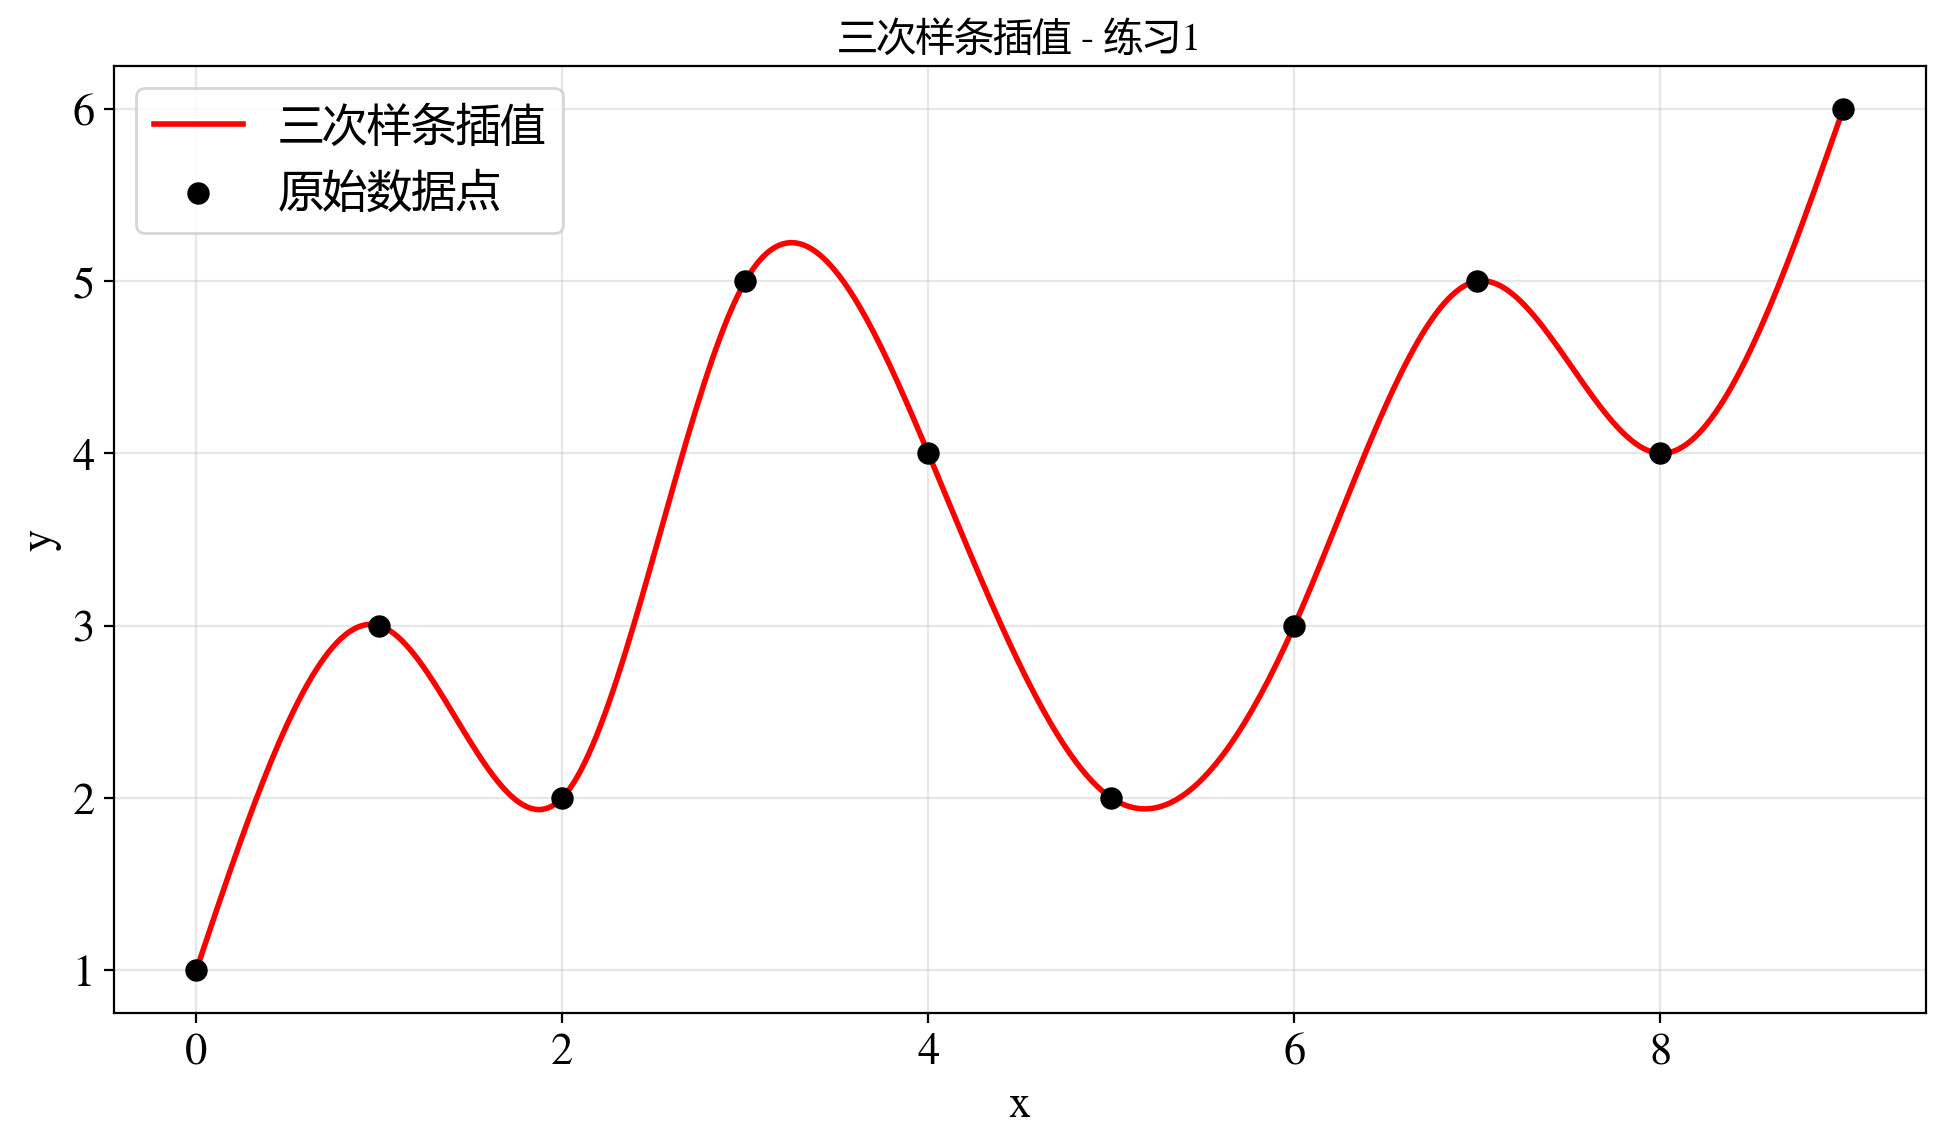

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 给定数据
x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
y = [1, 3, 2, 5, 4, 2, 3, 5, 4, 6]

# 构造三次样条插值器
cs = CubicSpline(x, y, bc_type='natural')

# 在区间 [0, 9] 上生成 400 个均匀点
xx = np.linspace(0, 9, 400)
yy = cs(xx)

# 绘图
plt.figure(figsize=(10, 6))
plt.plot(xx, yy, 'r-', linewidth=2, label='三次样条插值')
plt.scatter(x, y, color='black', s=50, zorder=5, label='原始数据点')
plt.title('三次样条插值 - 练习1', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

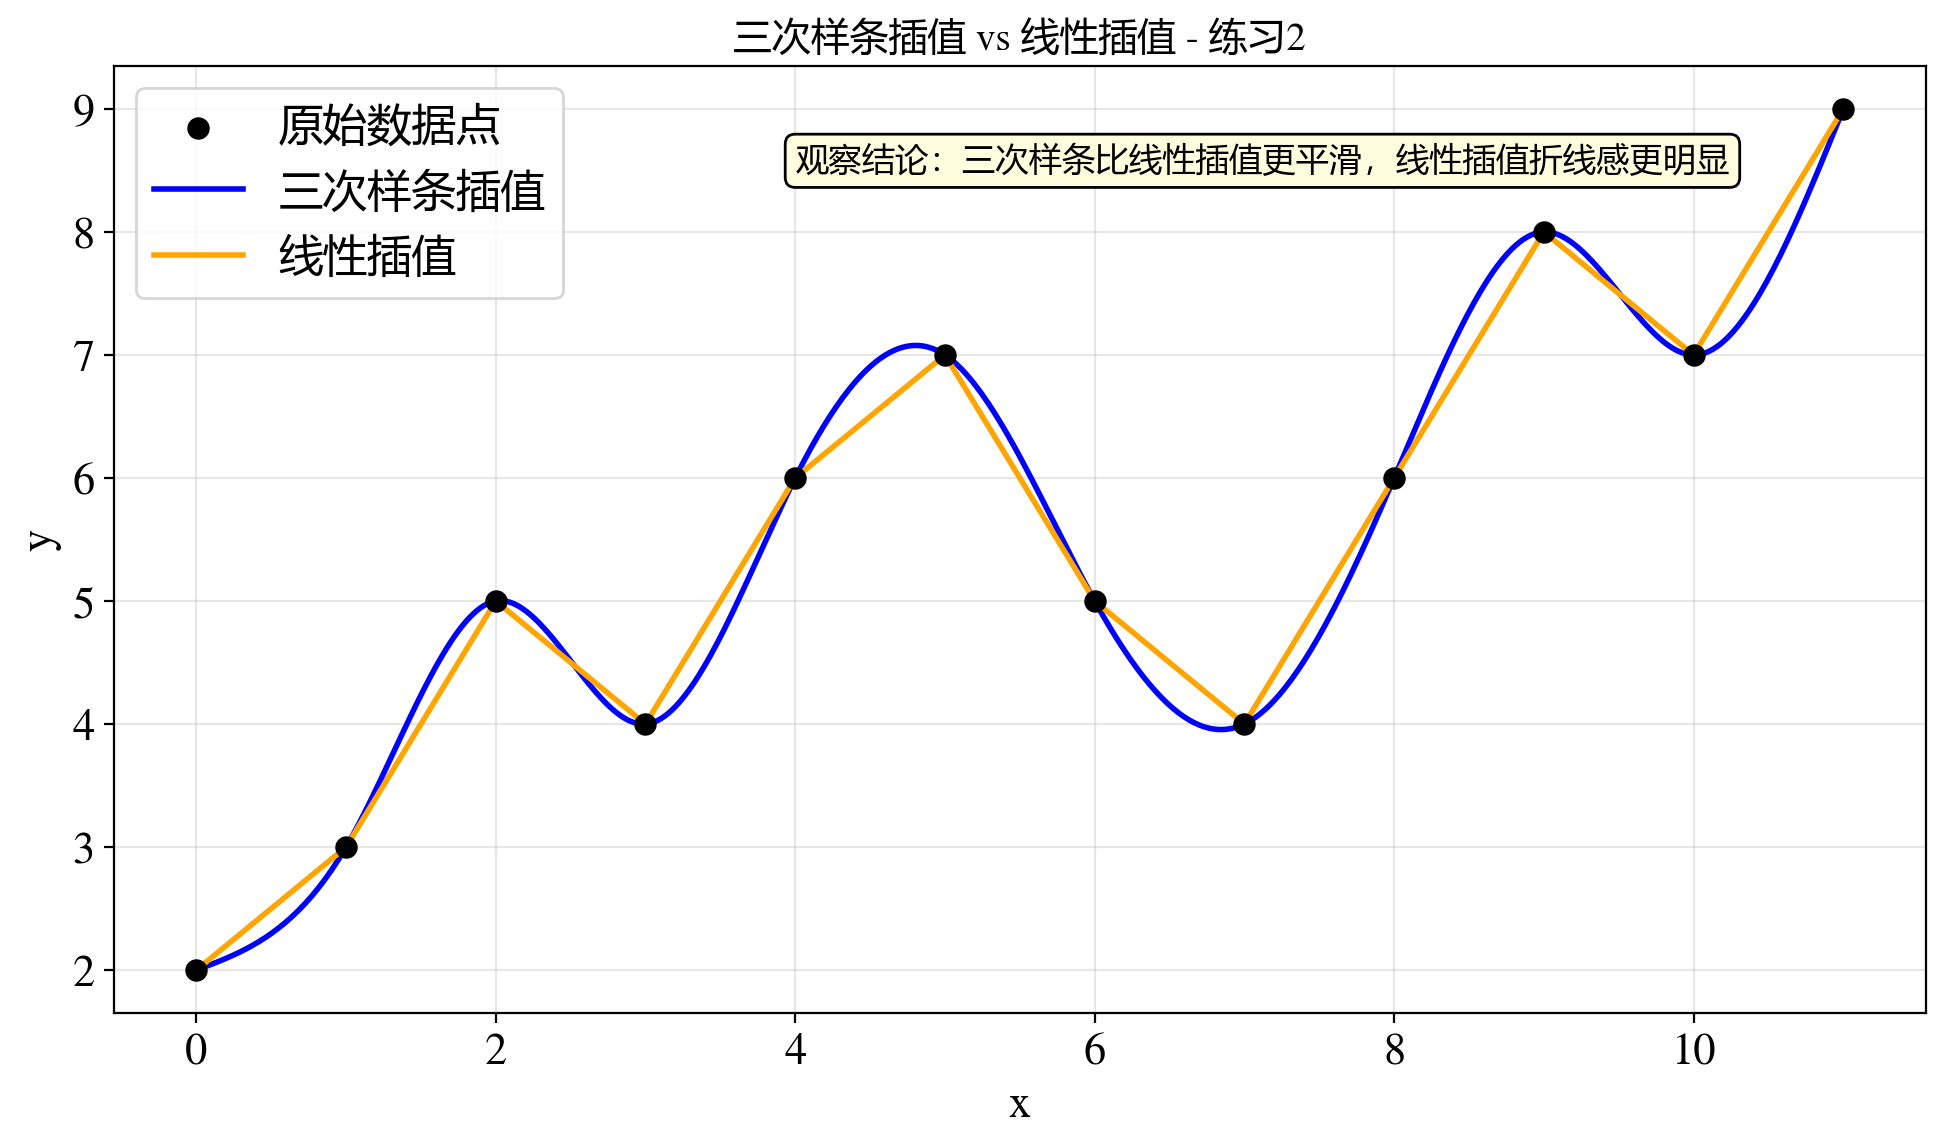

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, interp1d

# 给定数据
x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
y = [2, 3, 5, 4, 6, 7, 5, 4, 6, 8, 7, 9]

# 构造插值器
cs = CubicSpline(x, y, bc_type='natural')  # 三次样条插值
lin = interp1d(x, y, kind='linear')        # 线性插值

# 在区间 [0, 11] 上生成 500 个点
xx = np.linspace(0, 11, 500)
yy_cs = cs(xx)
yy_lin = lin(xx)

# 绘图
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', s=50, zorder=5, label='原始数据点')
plt.plot(xx, yy_cs, 'b-', linewidth=2, label='三次样条插值')
plt.plot(xx, yy_lin, 'orange', linewidth=2, label='线性插值')
plt.title('三次样条插值 vs 线性插值 - 练习2', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()

# 添加观察结论
plt.text(4, 8.5, '观察结论：三次样条比线性插值更平滑，线性插值折线感更明显', 
         fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

plt.tight_layout()
plt.show()

## 牛顿插值法课堂练习题

1.  给定三个节点：

$$
(1,2),\quad (2,3),\quad (4,1).
$$


2. 给定四个节点：

$$
(0,1),\quad (1,4),\quad (3,2),\quad (4,5).
$$


In [39]:
import numpy as np
import matplotlib.pyplot as plt

def newton_divided_diff(x, y):
    """
    构造差商表，返回 Newton 插值的系数数组 a
    """
    n = len(x)
    coef = np.copy(y).astype(float)  # 第一列

    for j in range(1, n):
        coef[j:] = (coef[j:] - coef[j-1:-1]) / (x[j:] - x[:-j])
    return coef

def newton_poly(coef, x_data, x):
    """
    根据系数 coef 和节点 x_data 计算多项式在 x 的值
    """
    n = len(coef)
    p = coef[-1]
    for k in range(n-2, -1, -1):
        p = p * (x - x_data[k]) + coef[k]
    return p



练习1 Newton 系数: [ 2.          1.         -0.66666667]


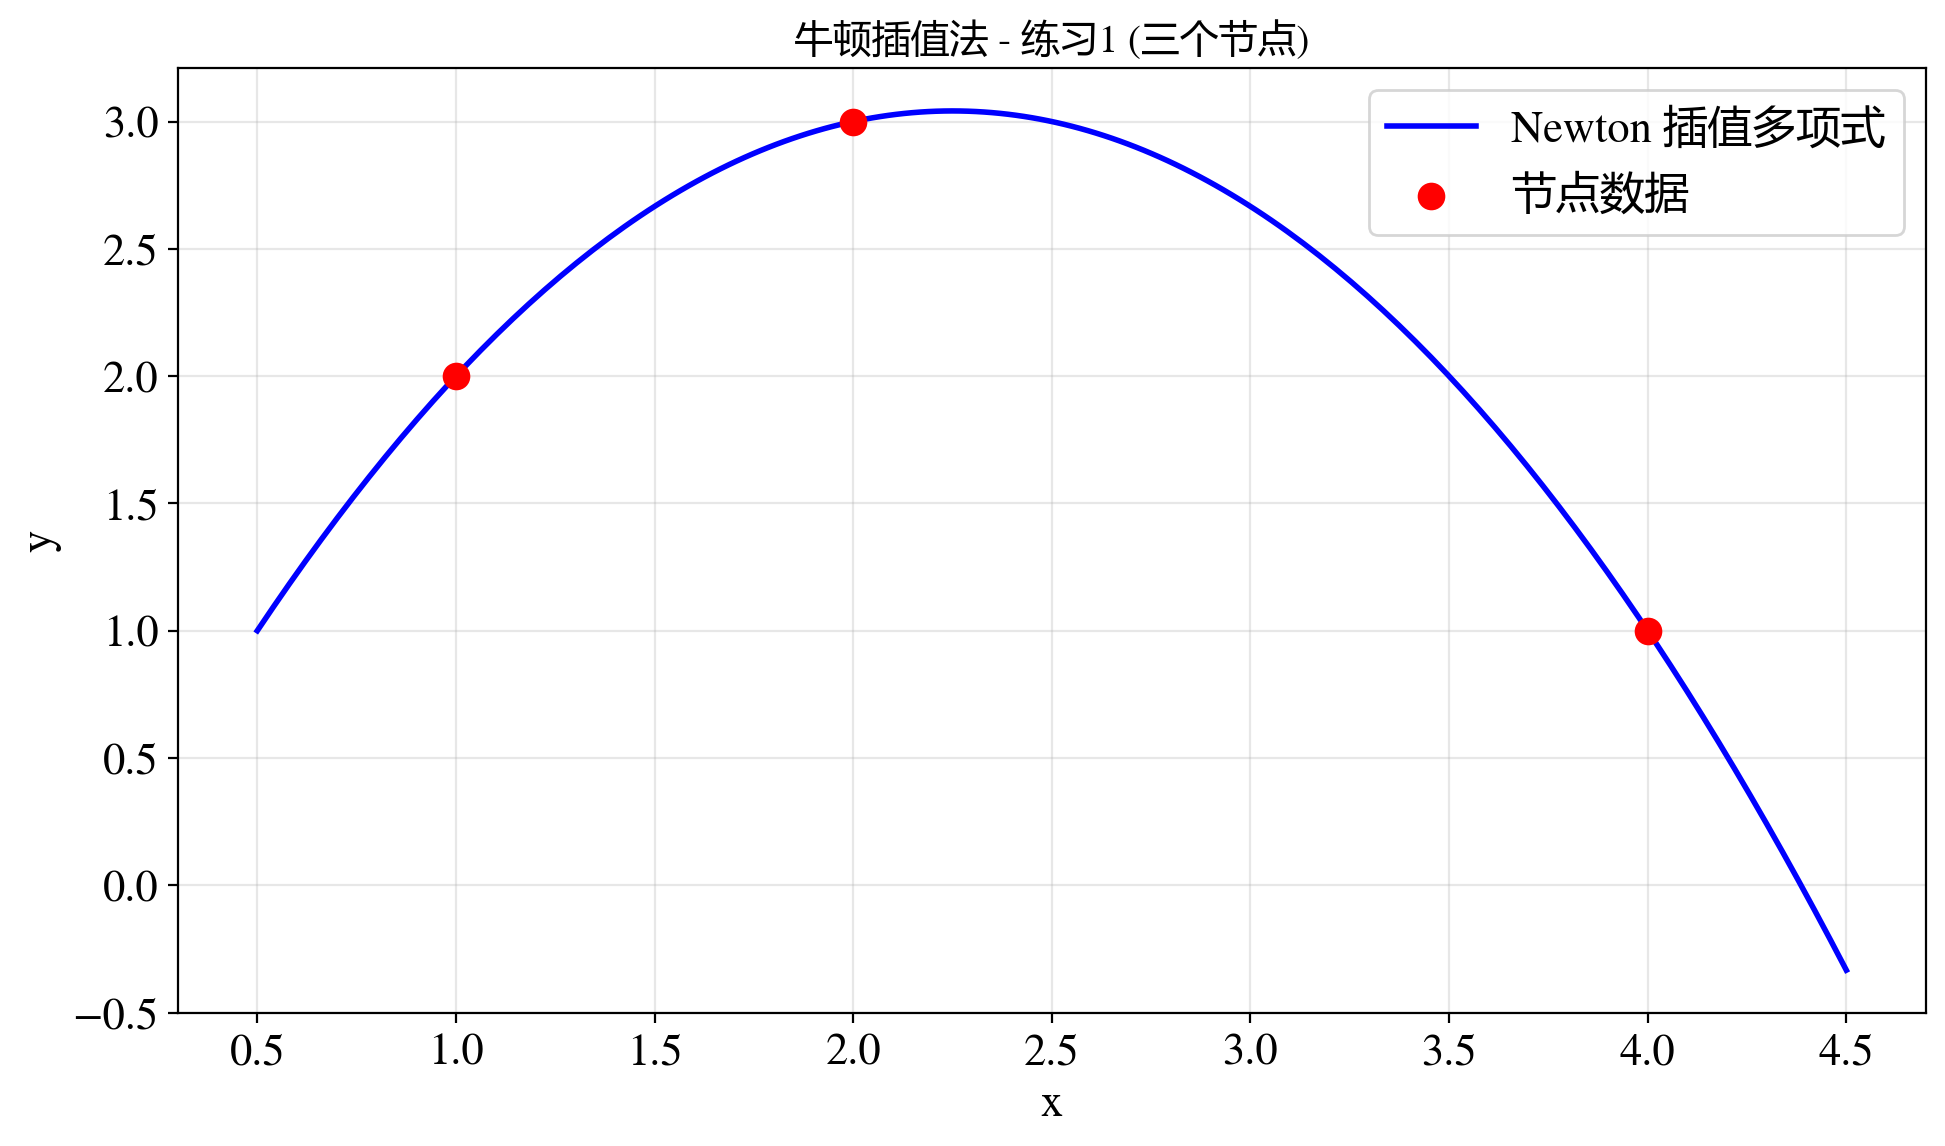

In [40]:
# 节点数据
x1 = np.array([1, 2, 4], dtype=float)
y1 = np.array([2, 3, 1], dtype=float)

# 构造牛顿插值系数
a1 = newton_divided_diff(x1, y1)
print("练习1 Newton 系数:", a1)

# 生成查询网格
xx1 = np.linspace(0.5, 4.5, 200)
yy1 = newton_poly(a1, x1, xx1)

# 画图
plt.figure(figsize=(10, 6))
plt.plot(xx1, yy1, 'b-', linewidth=2, label='Newton 插值多项式')
plt.scatter(x1, y1, color='red', s=80, zorder=5, label='节点数据')
plt.title('牛顿插值法 - 练习1 (三个节点)', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

练习2 Newton 系数: [ 1.          3.         -1.33333333  0.66666667]


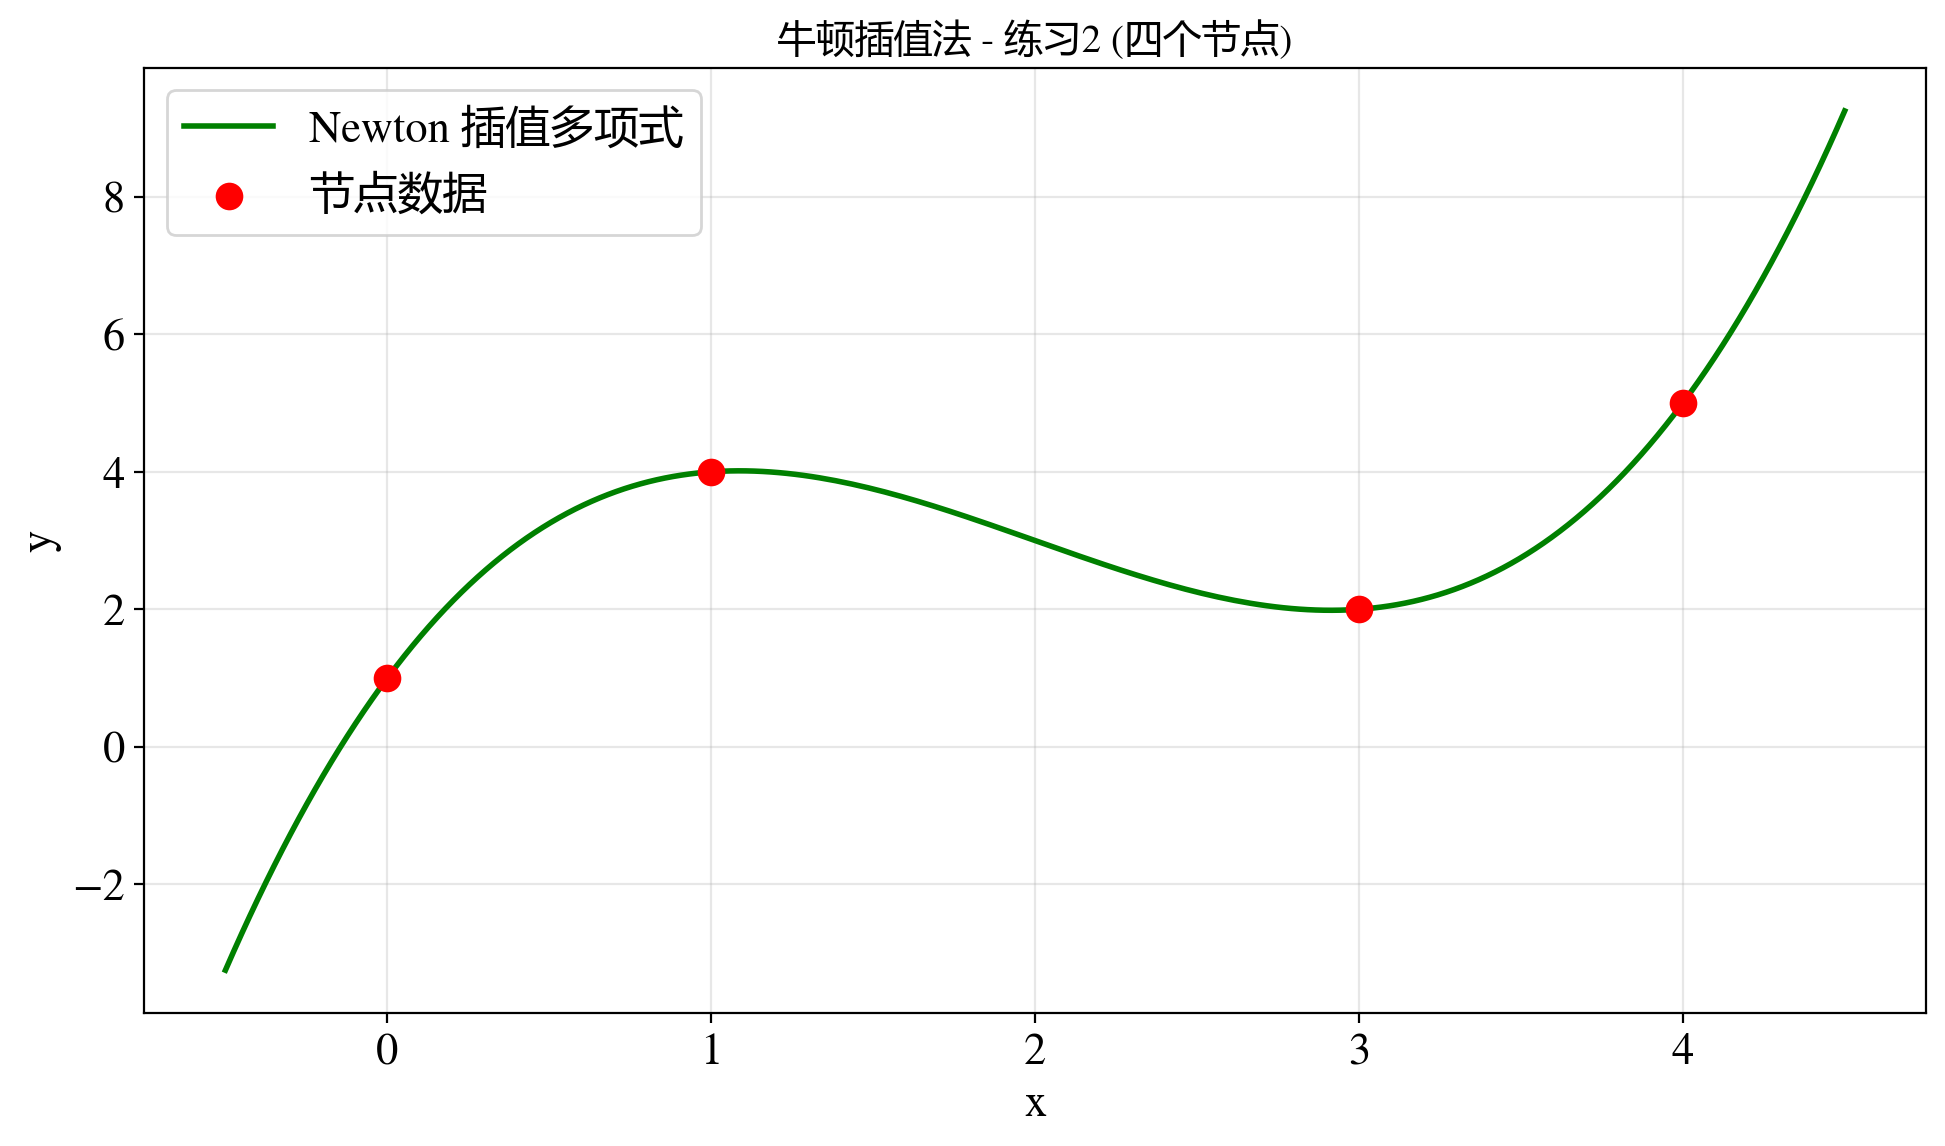

In [41]:
# 节点数据
x2 = np.array([0, 1, 3, 4], dtype=float)
y2 = np.array([1, 4, 2, 5], dtype=float)

# 构造牛顿插值系数
a2 = newton_divided_diff(x2, y2)
print("练习2 Newton 系数:", a2)

# 生成查询网格
xx2 = np.linspace(-0.5, 4.5, 200)
yy2 = newton_poly(a2, x2, xx2)

# 画图
plt.figure(figsize=(10, 6))
plt.plot(xx2, yy2, 'g-', linewidth=2, label='Newton 插值多项式')
plt.scatter(x2, y2, color='red', s=80, zorder=5, label='节点数据')
plt.title('牛顿插值法 - 练习2 (四个节点)', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 课堂练习

练习 1：用于拟合直线 `p(x)=a+bx`
```python
x = [0, 1, 2, 3, 4, 5]
y = [1.2, 2.1, 2.9, 4.2, 4.0, 6.1]
```

练习 2：用于拟合二次多项式和三次多项式

```python
x = [0, 1, 2, 3, 4, 5]
y = [1.0, 1.8, 3.5, 5.1, 7.2, 9.1]
```


练习1 - 线性拟合结果:
多项式: p(x) = 1.1667 + 0.9000x
残差平方和: 0.8933


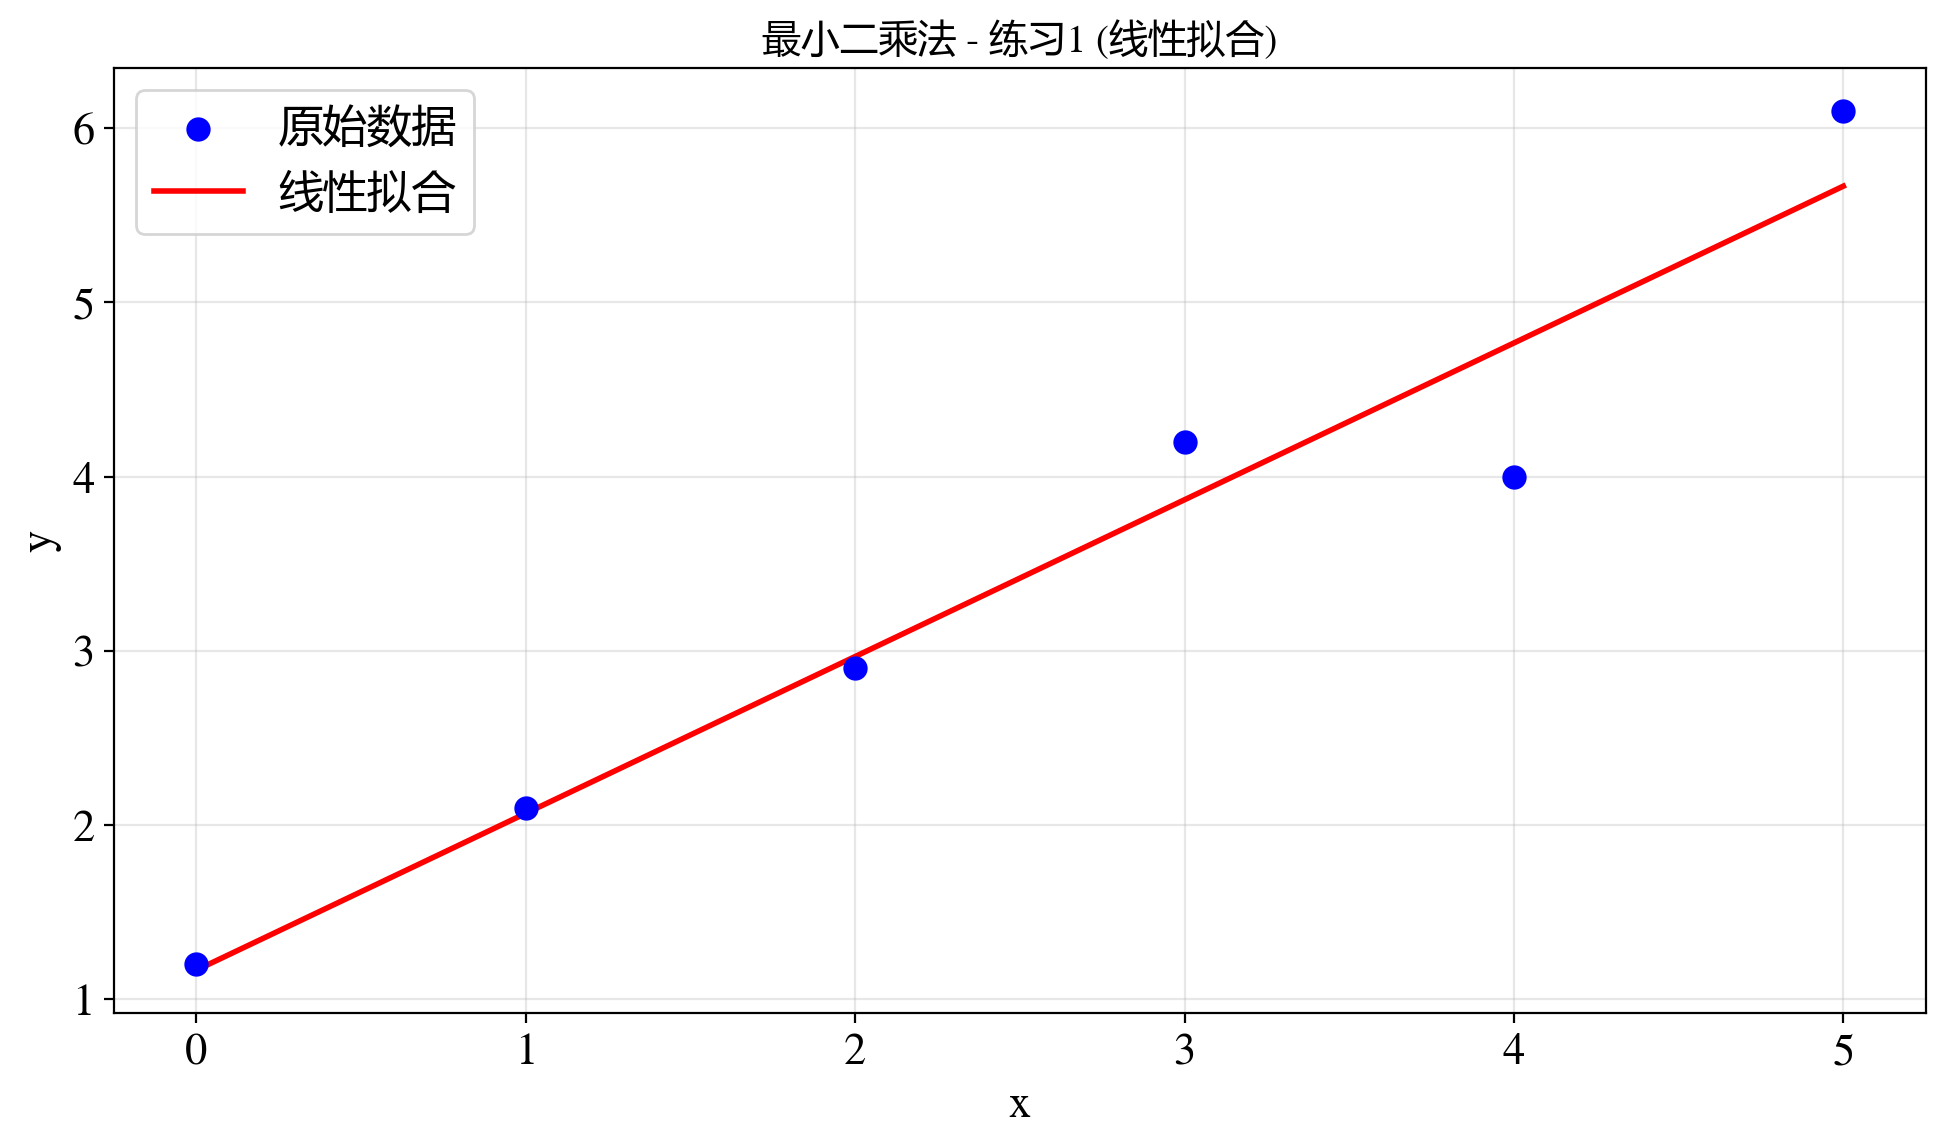

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# 练习1：线性拟合
x1 = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y1 = np.array([1.2, 2.1, 2.9, 4.2, 4.0, 6.1], dtype=float)

# 构建设计矩阵 A = [1, x]
A1 = np.column_stack([np.ones_like(x1), x1])

# 最小二乘求解
coef1, residual1, _, _ = np.linalg.lstsq(A1, y1, rcond=None)
print(f"练习1 - 线性拟合结果:")
print(f"多项式: p(x) = {coef1[0]:.4f} + {coef1[1]:.4f}x")
print(f"残差平方和: {residual1[0]:.4f}")

# 绘图
xx1 = np.linspace(0, 5, 200)
yy1 = coef1[0] + coef1[1] * xx1

plt.figure(figsize=(10, 6))
plt.scatter(x1, y1, color='blue', s=60, label='原始数据', zorder=5)
plt.plot(xx1, yy1, 'r-', linewidth=2, label='线性拟合')
plt.title('最小二乘法 - 练习1 (线性拟合)', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


练习2 - 二次多项式拟合结果:
多项式: p(x) = 0.8750 + 1.0318x + 0.1268x²
残差平方和: 0.1126

练习2 - 三次多项式拟合结果:
多项式: p(x) = 0.9778 + 0.5624x + 0.3837x² + -0.0343x³
残差平方和: 0.0366


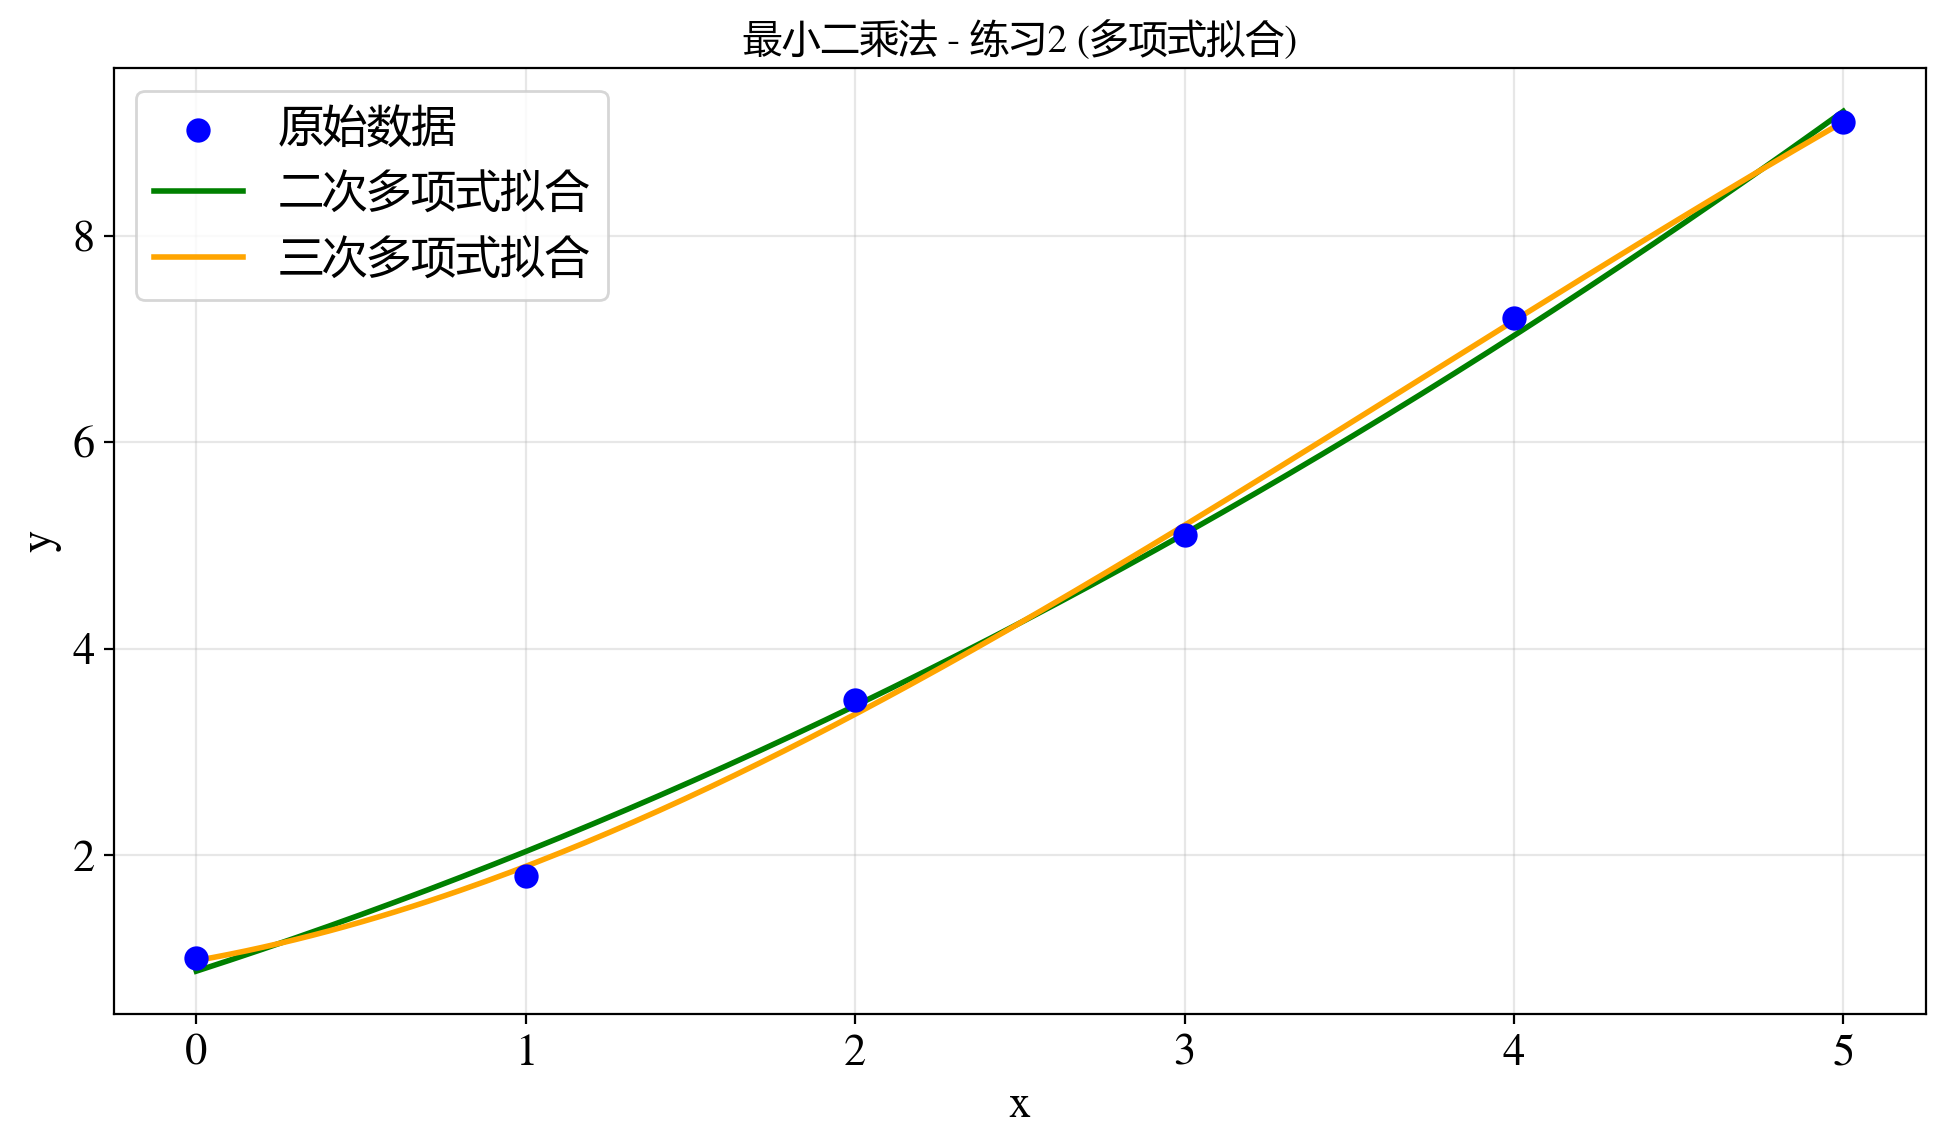

In [44]:
# 练习2：二次和三次多项式拟合
x2 = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y2 = np.array([1.0, 1.8, 3.5, 5.1, 7.2, 9.1], dtype=float)

# 构造二次多项式设计矩阵 A = [1, x, x²]
A2_quad = np.column_stack([np.ones_like(x2), x2, x2**2])

# 构造三次多项式设计矩阵 A = [1, x, x², x³]
A2_cubic = np.column_stack([np.ones_like(x2), x2, x2**2, x2**3])

# 最小二乘求解
coef2_quad, residual2_quad, _, _ = np.linalg.lstsq(A2_quad, y2, rcond=None)
coef2_cubic, residual2_cubic, _, _ = np.linalg.lstsq(A2_cubic, y2, rcond=None)

print(f"\n练习2 - 二次多项式拟合结果:")
print(f"多项式: p(x) = {coef2_quad[0]:.4f} + {coef2_quad[1]:.4f}x + {coef2_quad[2]:.4f}x²")
print(f"残差平方和: {residual2_quad[0]:.4f}")

print(f"\n练习2 - 三次多项式拟合结果:")
print(f"多项式: p(x) = {coef2_cubic[0]:.4f} + {coef2_cubic[1]:.4f}x + {coef2_cubic[2]:.4f}x² + {coef2_cubic[3]:.4f}x³")
print(f"残差平方和: {residual2_cubic[0]:.4f}")

# 绘图
xx2 = np.linspace(0, 5, 200)
yy2_quad = coef2_quad[0] + coef2_quad[1]*xx2 + coef2_quad[2]*(xx2**2)
yy2_cubic = coef2_cubic[0] + coef2_cubic[1]*xx2 + coef2_cubic[2]*(xx2**2) + coef2_cubic[3]*(xx2**3)

plt.figure(figsize=(10, 6))
plt.scatter(x2, y2, color='blue', s=60, label='原始数据', zorder=5)
plt.plot(xx2, yy2_quad, 'g-', linewidth=2, label='二次多项式拟合')
plt.plot(xx2, yy2_cubic, 'orange', linewidth=2, label='三次多项式拟合')
plt.title('最小二乘法 - 练习2 (多项式拟合)', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 课堂练习：用三次样条逼近连续函数

目标是使用 **三次样条（Cubic Spline）** 来逼近一个平滑但变化较快的函数。

---

## 📘 练习题

在区间 $ [0, 2] $ 上，考虑函数：

$$
f(x) = e^{-x} \sin(3x)
$$

请按照以下步骤完成拟合和分析。

### （1）在区间 \( [0, 2] \) 上取 200 个等距节点  
生成采样数据：
$$
x_i,\quad y_i = f(x_i)
$$

### （2）使用 `UnivariateSpline` 对数据做三次样条逼近  
选择一个合适的平滑参数 `s`（如 0.001–0.01）。

### （3）在更密集的网格（400 点）上绘制：
- 原函数曲线 $ f(x) $
- 样条逼近曲线 $ s(x) $

### （4）绘制误差曲线
$$
e(x) = f(x) - s(x)
$

### （5）讨论问题
- 样条在哪些区间逼近得最好？  
- 平滑参数 `s` 越大/越小，会带来怎样的变化？  
- 若函数振荡更快，样条拟合需要哪些调整？

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# 定义目标函数
def f(x):
    return np.exp(-x) * np.sin(3*x)

# (1) 在区间 [0, 2] 上取 200 个等距节点
x_data = np.linspace(0, 2, 200)
y_data = f(x_data)

print(f"采样数据信息:")
print(f"采样点数量: {len(x_data)}")
print(f"x 范围: [{x_data[0]:.2f}, {x_data[-1]:.2f}]")
print(f"y 范围: [{np.min(y_data):.4f}, {np.max(y_data):.4f}]")

采样数据信息:
采样点数量: 200
x 范围: [0.00, 2.00]
y 范围: [-0.2195, 0.6256]


In [104]:
# (2) 使用 UnivariateSpline 对数据做三次样条逼近
# 选择合适的平滑参数 s = 0.005
s = 0.005
spline = UnivariateSpline(x_data, y_data, s=s)

print(f"三次样条逼近参数:")
print(f"平滑参数 s = {s}")
print(f"样条节点数: {spline.get_knots().size}")
print(f"样条阶数: 3 (UnivariateSpline 默认使用三次样条)")  # 修正：直接说明阶数

# 验证样条在节点处的拟合效果
y_spline_at_nodes = spline(x_data)
residuals = y_data - y_spline_at_nodes
print(f"节点处残差统计:")
print(f"  最大残差: {np.max(np.abs(residuals)):.6f}")
print(f"  平均残差: {np.mean(np.abs(residuals)):.6f}")
print(f"  残差平方和: {np.sum(residuals**2):.6f}")

# 获取样条的其他信息
knots = spline.get_knots()
print(f"样条节点位置: {knots}")
print(f"样条系数数量: {len(spline.get_coeffs())}")

三次样条逼近参数:
平滑参数 s = 0.005
样条节点数: 5
样条阶数: 3 (UnivariateSpline 默认使用三次样条)
节点处残差统计:
  最大残差: 0.019507
  平均残差: 0.004143
  残差平方和: 0.005000
样条节点位置: [0.         0.50251256 1.00502513 1.50753769 2.        ]
样条系数数量: 7


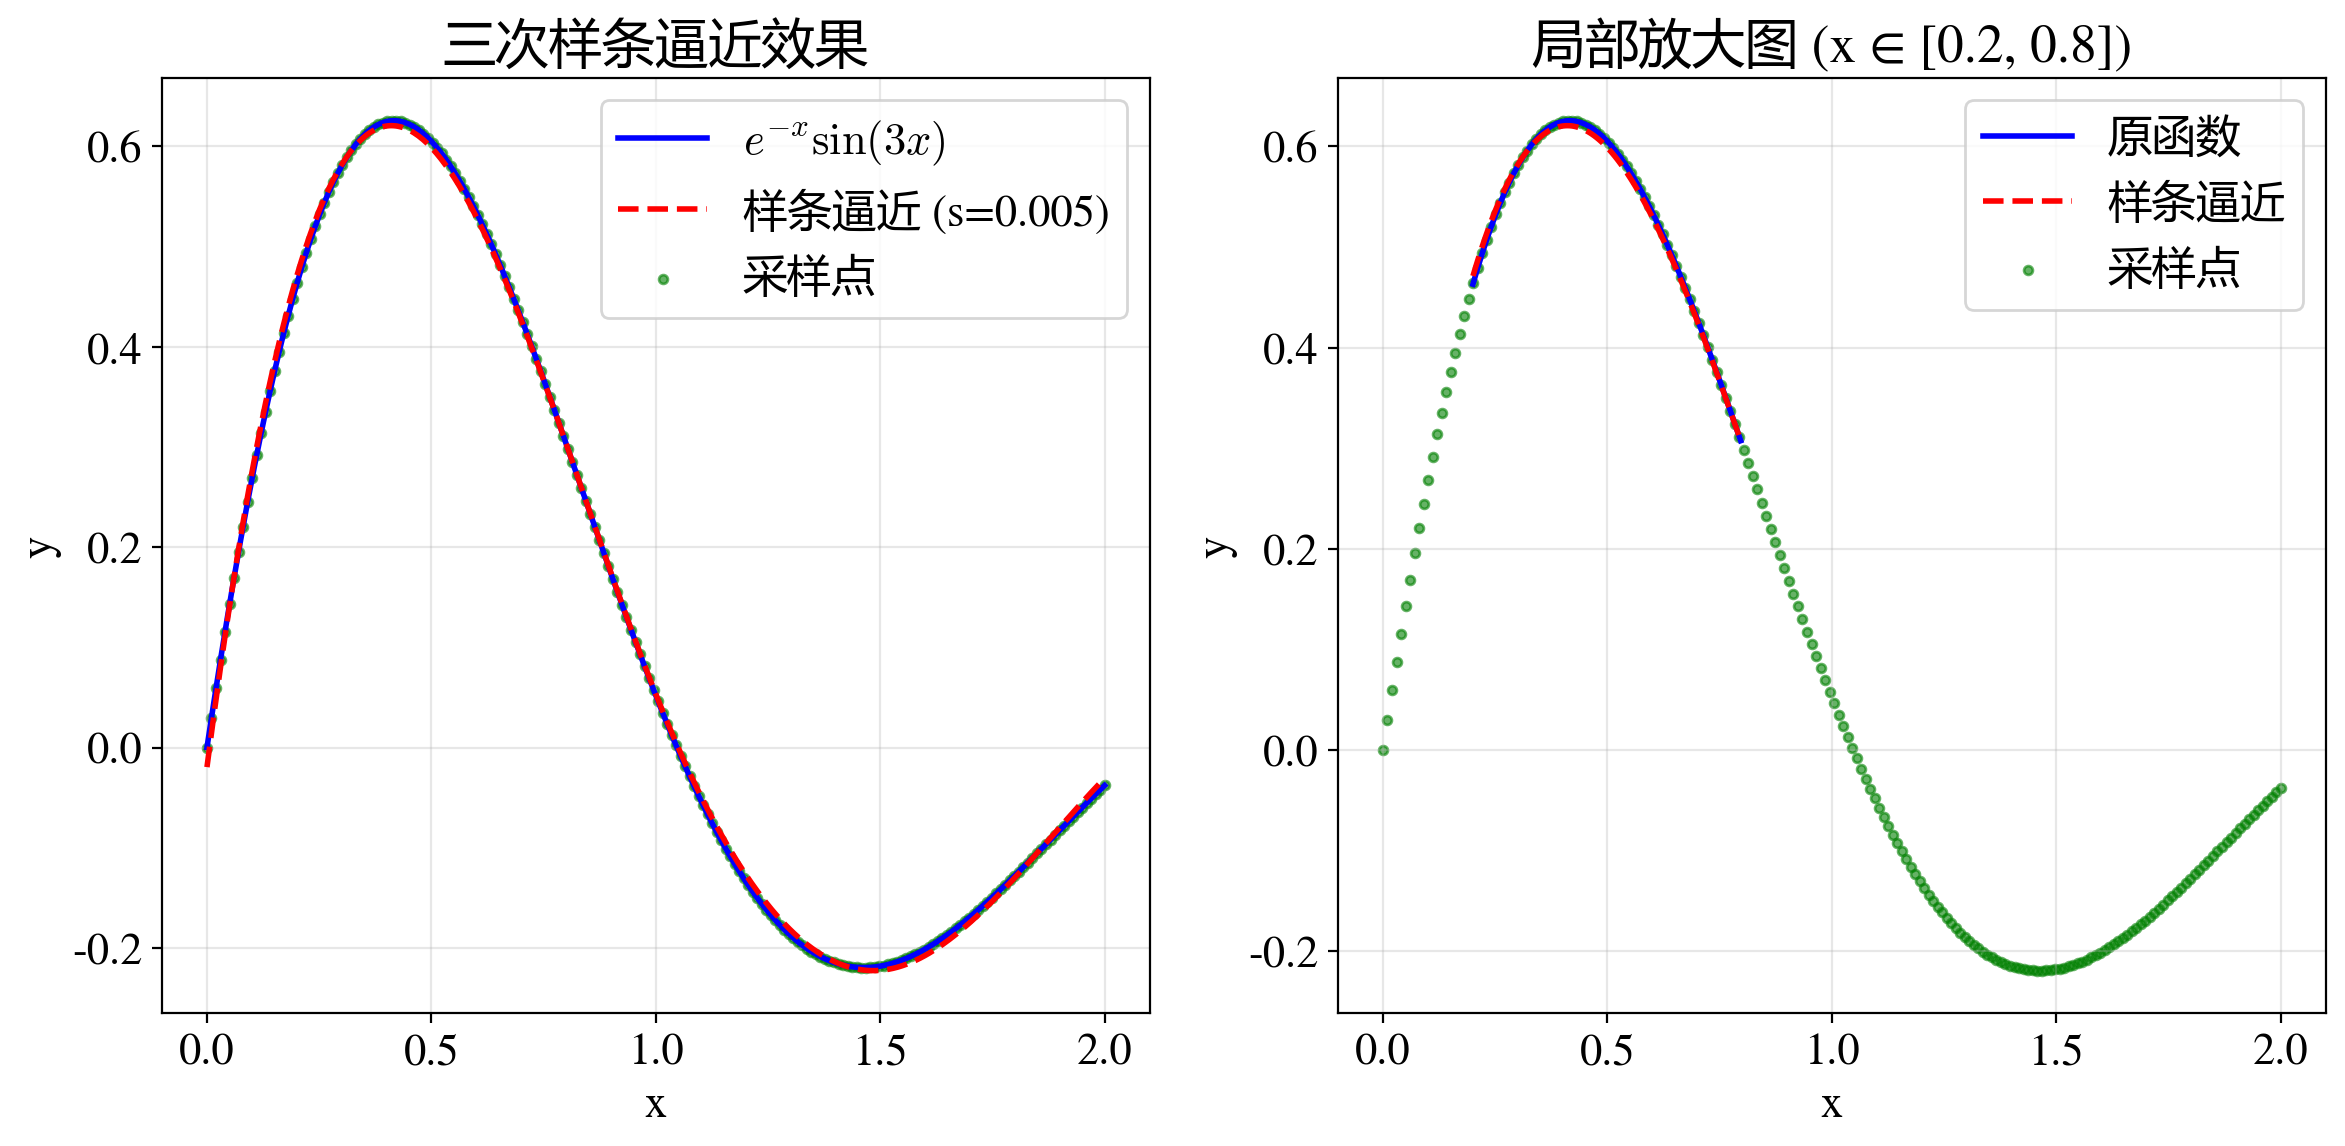

In [108]:
# (3) 在更密集的网格（400 点）上绘制原函数和样条逼近曲线
xx = np.linspace(0, 2, 400)
yy_true = f(xx)
yy_spline = spline(xx)

plt.figure(figsize=(12, 6))

# 绘制原函数和样条逼近
plt.subplot(1, 2, 1)
plt.plot(xx, yy_true, 'b-', linewidth=2, label='$e^{-x}\\sin(3x)$')
plt.plot(xx, yy_spline, 'r--', linewidth=2, label=f'样条逼近 (s={s})')
plt.scatter(x_data, y_data, color='green', s=10, alpha=0.6, label='采样点')
plt.xlabel('x')
plt.ylabel('y')
plt.title('三次样条逼近效果')
plt.grid(alpha=0.3)
plt.legend()

# 绘制局部放大图（观察振荡区域）
plt.subplot(1, 2, 2)
zoom_range = (xx >= 0.2) & (xx <= 0.8)
plt.plot(xx[zoom_range], yy_true[zoom_range], 'b-', linewidth=2, label='原函数')
plt.plot(xx[zoom_range], yy_spline[zoom_range], 'r--', linewidth=2, label='样条逼近')
plt.scatter(x_data, y_data, color='green', s=10, alpha=0.6, label='采样点')
plt.xlabel('x')
plt.ylabel('y')
plt.title('局部放大图 (x ∈ [0.2, 0.8])')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

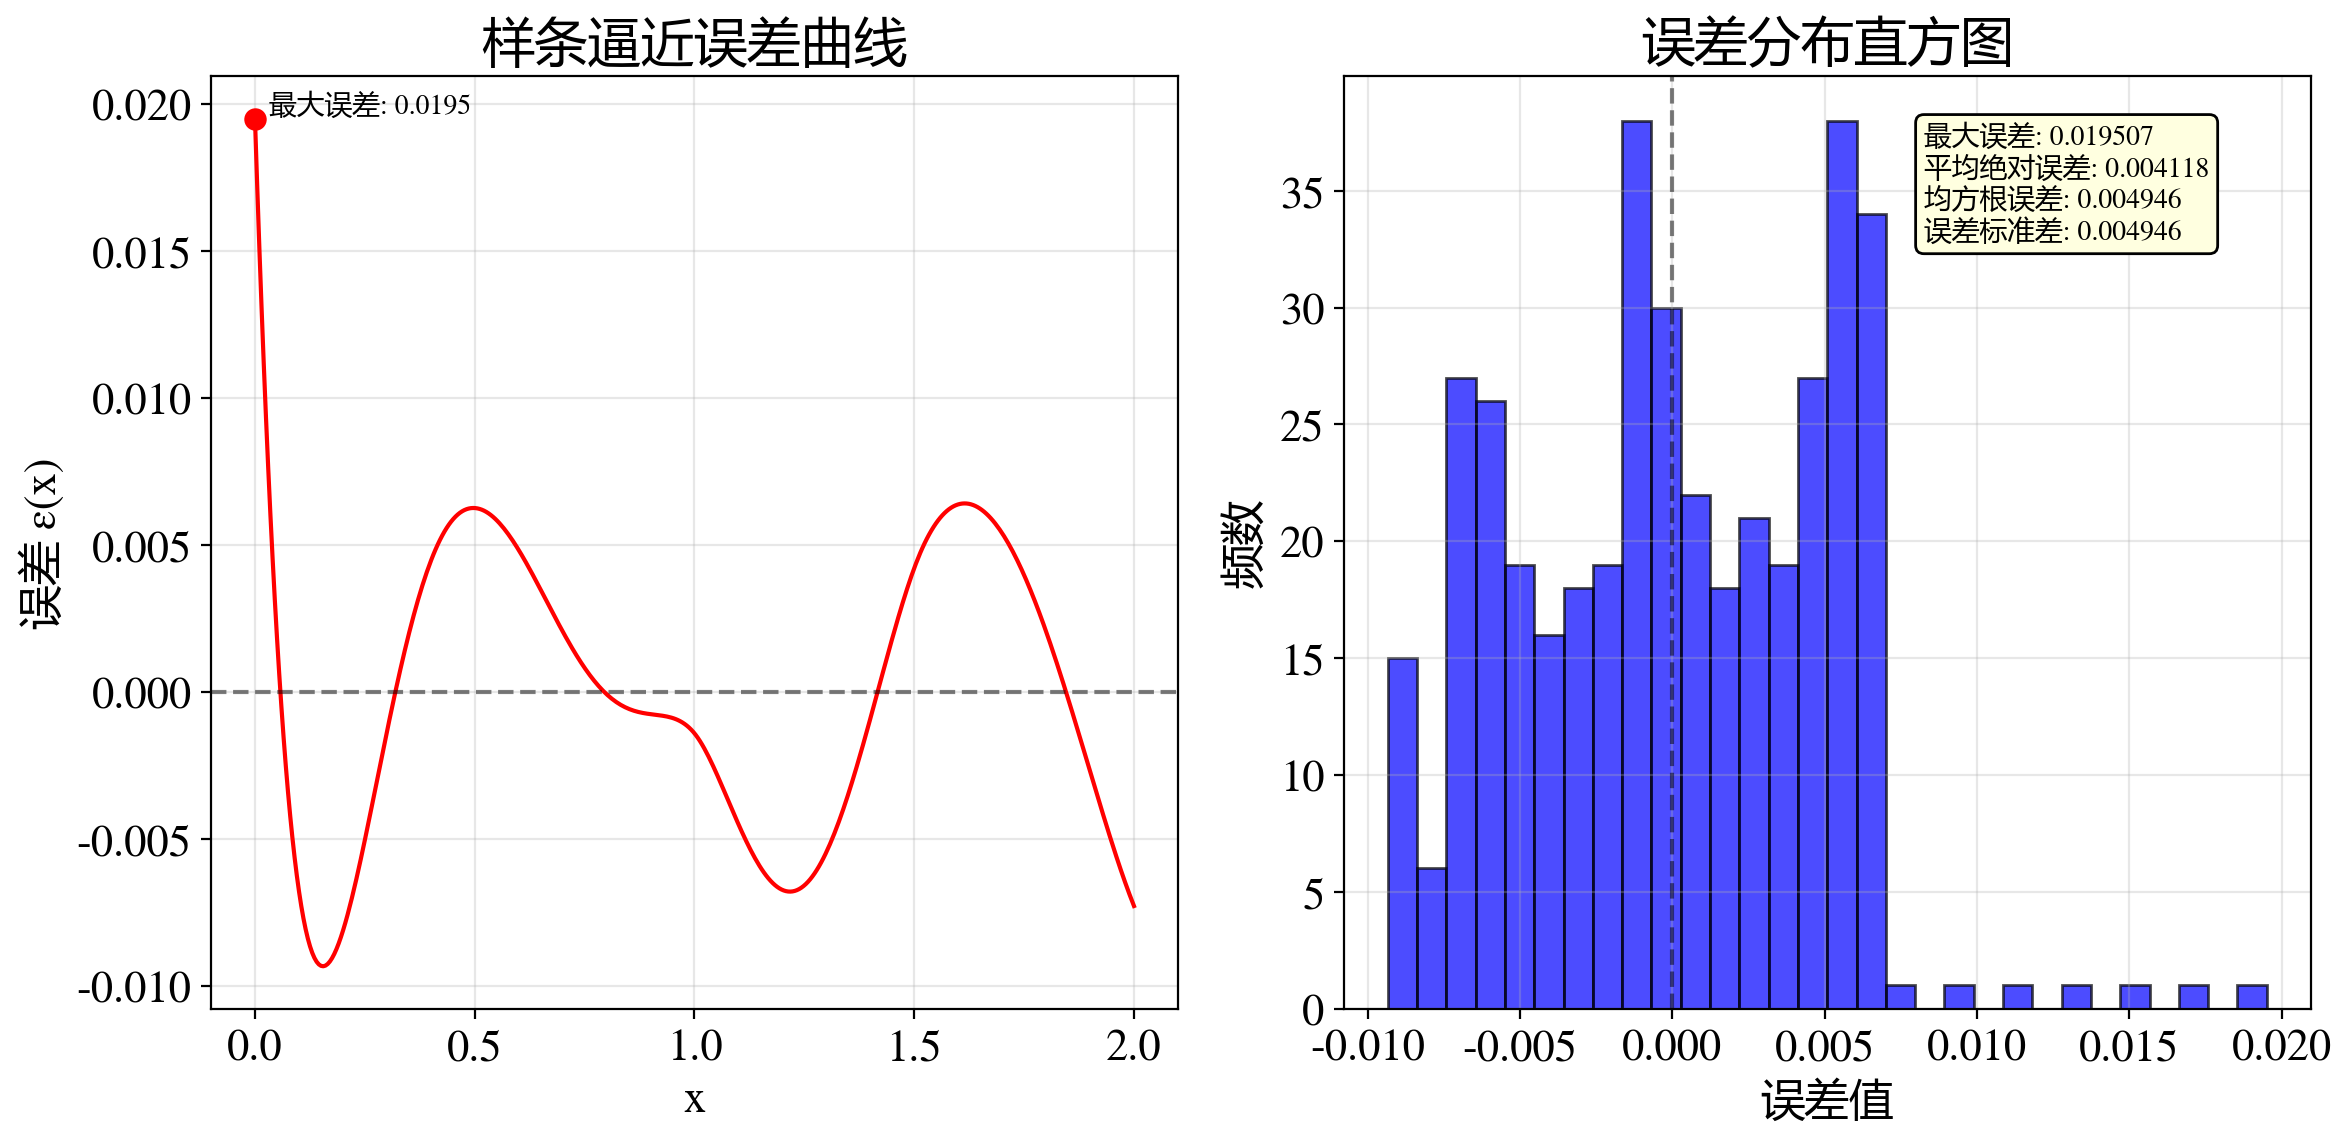

In [116]:
# (4) 绘制误差曲线 ε(x) = f(x) - s(x)
error = yy_true - yy_spline

plt.figure(figsize=(12, 6))

# 绘制误差曲线
plt.subplot(1, 2, 1)
plt.plot(xx, error, 'r-', linewidth=1.5)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('误差 ε(x)')
plt.title('样条逼近误差曲线')
plt.grid(alpha=0.3)

# 标注最大误差位置
max_error_idx = np.argmax(np.abs(error))
max_error_x = xx[max_error_idx]
max_error_val = error[max_error_idx]
plt.scatter(max_error_x, max_error_val, color='red', s=50, zorder=5)
plt.text(max_error_x, max_error_val, f'  最大误差: {max_error_val:.4f}', 
         fontsize=10, verticalalignment='bottom' if max_error_val > 0 else 'top')

# 绘制误差统计直方图
plt.subplot(1, 2, 2)
plt.hist(error, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('误差值')
plt.ylabel('频数')
plt.title('误差分布直方图')
plt.grid(alpha=0.3)

# 添加误差统计信息
error_stats = {
    '最大误差': np.max(np.abs(error)),
    '平均绝对误差': np.mean(np.abs(error)),
    '均方根误差': np.sqrt(np.mean(error**2)),
    '误差标准差': np.std(error)
}

plt.text(0.6, 0.95, '\n'.join([f'{k}: {v:.6f}' for k, v in error_stats.items()]),
         transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"),
         verticalalignment='top')

plt.tight_layout()
plt.show()

=== 讨论问题分析 ===
区间 [0, 0.5]: 最大误差 = 0.019507
区间 [0.5, 1.0]: 最大误差 = 0.006254
区间 [1.0, 1.5]: 最大误差 = 0.006797
区间 [1.5, 2.0]: 最大误差 = 0.007288

1. 样条在区间 [0.5, 1.0] 逼近得最好
   在区间 [0, 0.5] 误差最大

2. 平滑参数 s 的影响分析:


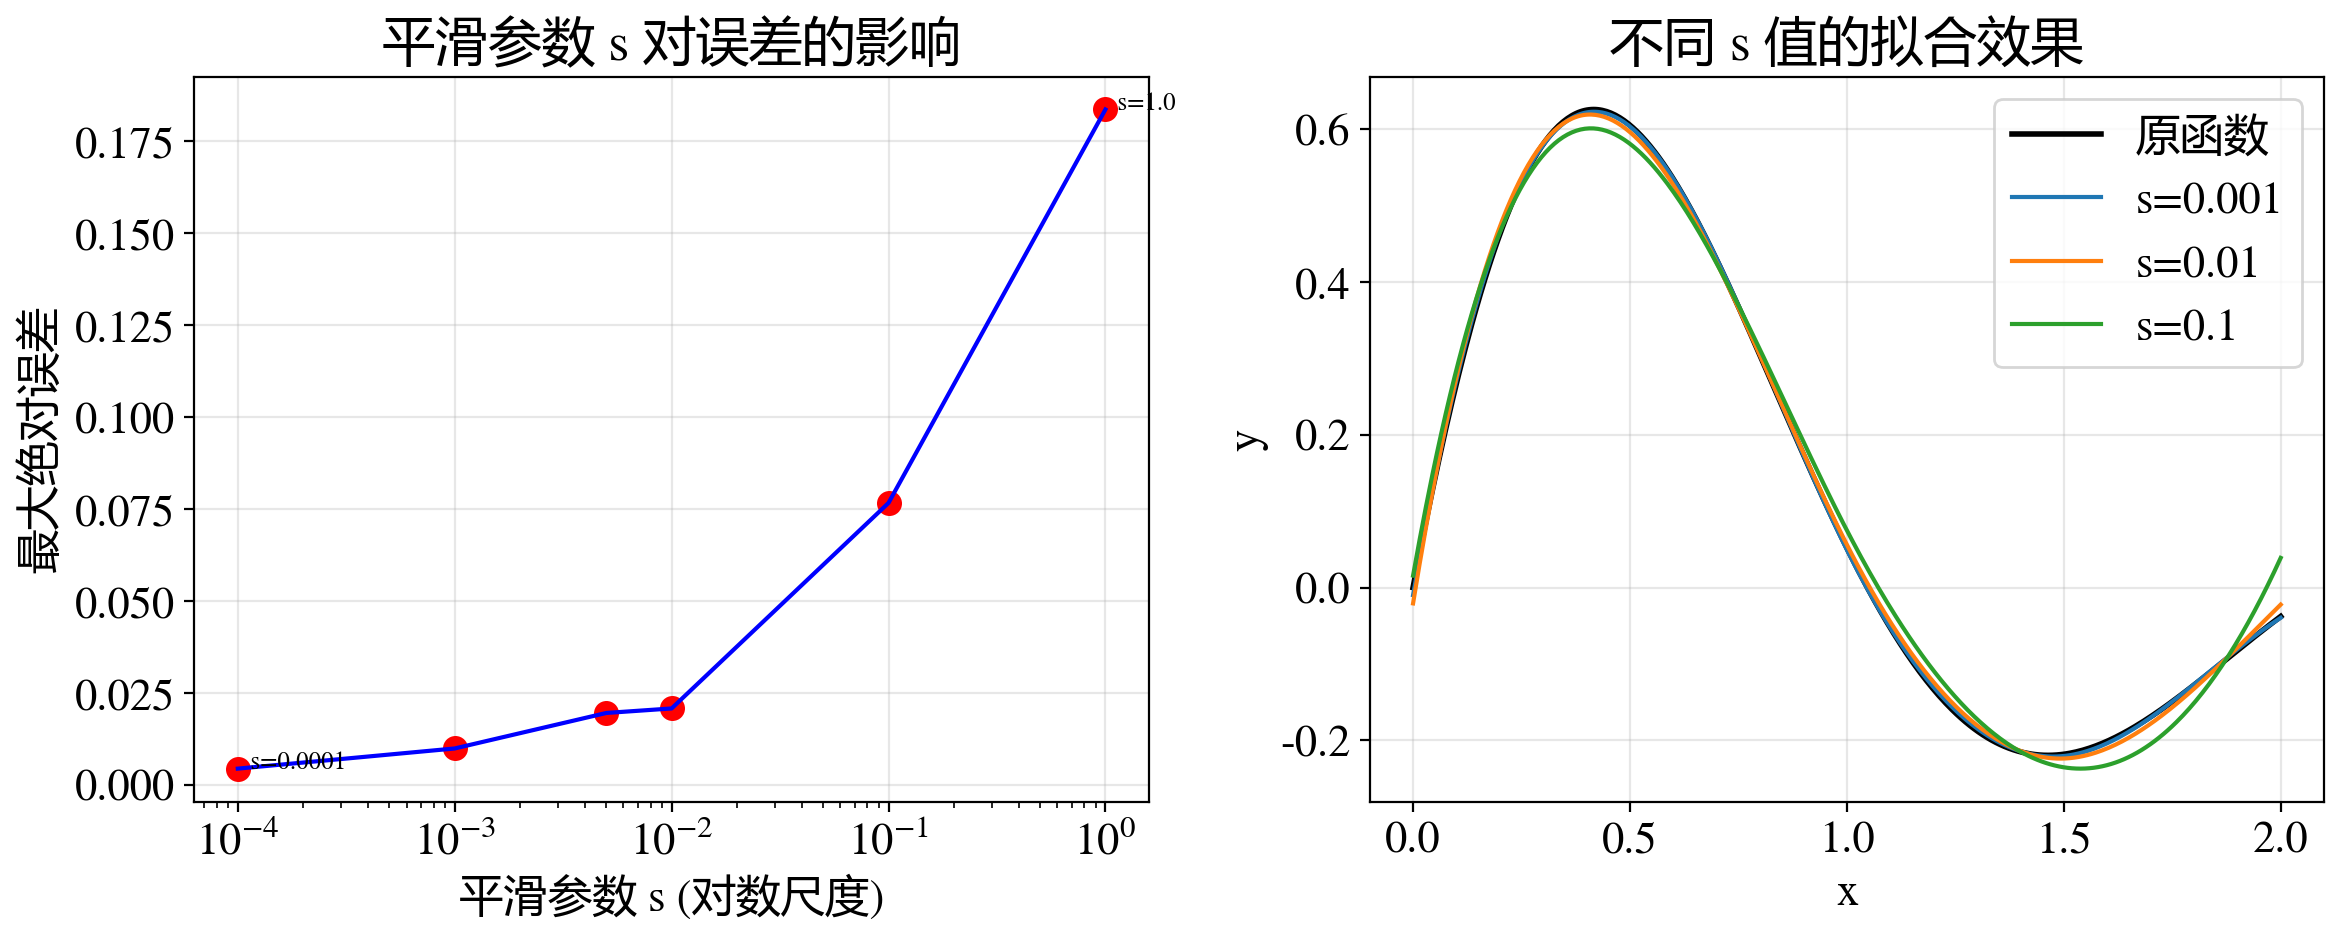


   平滑参数 s 的影响:
   - s 越小: 逼近更精确，但可能对噪声敏感，产生过拟合
   - s 越大: 曲线更平滑，但可能偏离真实函数，产生欠拟合

3. 若函数振荡更快，样条拟合需要调整:
   - 增加采样点密度，特别是振荡剧烈区域
   - 减小平滑参数 s 以更好地捕捉快速变化
   - 考虑使用自适应采样策略
   - 可能需要更高阶的样条或分段样条


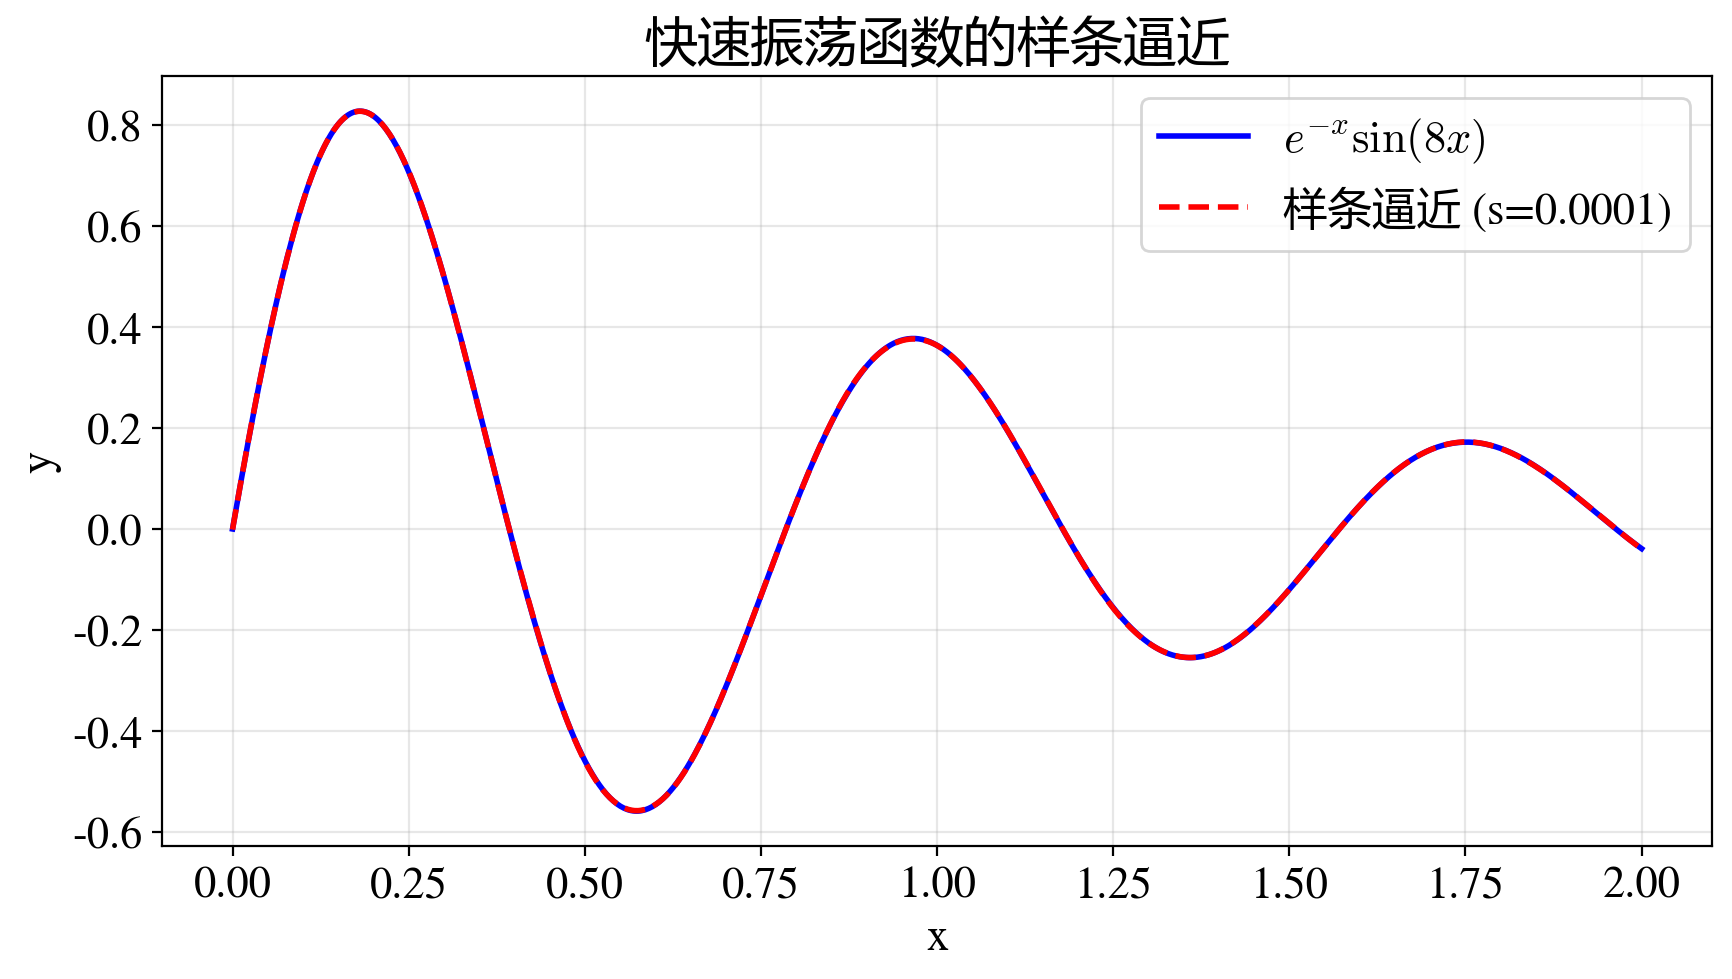

   快速振荡函数逼近的最大误差: 0.0013
   相比原函数误差增加了 0.07 倍


In [120]:
# (5) 讨论问题分析

print("=== 讨论问题分析 ===")

# 分析不同区间的逼近效果
intervals = [(0, 0.5), (0.5, 1.0), (1.0, 1.5), (1.5, 2.0)]
interval_errors = []

for i, (start, end) in enumerate(intervals):
    mask = (xx >= start) & (xx <= end)
    interval_error = np.max(np.abs(error[mask]))
    interval_errors.append(interval_error)
    print(f"区间 [{start}, {end}]: 最大误差 = {interval_error:.6f}")

best_interval_idx = np.argmin(interval_errors)
worst_interval_idx = np.argmax(interval_errors)
print(f"\n1. 样条在区间 [{intervals[best_interval_idx][0]}, {intervals[best_interval_idx][1]}] 逼近得最好")
print(f"   在区间 [{intervals[worst_interval_idx][0]}, {intervals[worst_interval_idx][1]}] 误差最大")

# 分析平滑参数 s 的影响
print("\n2. 平滑参数 s 的影响分析:")
s_test_values = [0.0001, 0.001, 0.005, 0.01, 0.1, 1.0]
s_errors = []

plt.figure(figsize=(12, 5))

for i, s_test in enumerate(s_test_values):
    spline_test = UnivariateSpline(x_data, y_data, s=s_test)
    yy_test = spline_test(xx)
    test_error = np.max(np.abs(yy_true - yy_test))
    s_errors.append(test_error)
    
    plt.subplot(1, 2, 1)
    plt.semilogx(s_test, test_error, 'ro', markersize=8)
    if i == 0 or i == len(s_test_values)-1:
        plt.text(s_test, test_error, f'  s={s_test}', fontsize=9)

plt.subplot(1, 2, 1)
plt.semilogx(s_test_values, s_errors, 'b-')
plt.xlabel('平滑参数 s (对数尺度)')
plt.ylabel('最大绝对误差')
plt.title('平滑参数 s 对误差的影响')
plt.grid(alpha=0.3)

# 演示不同 s 值的拟合效果
plt.subplot(1, 2, 2)
plt.plot(xx, yy_true, 'k-', linewidth=2, label='原函数')
for s_test in [0.001, 0.01, 0.1]:
    spline_test = UnivariateSpline(x_data, y_data, s=s_test)
    yy_test = spline_test(xx)
    plt.plot(xx, yy_test, linewidth=1.5, label=f's={s_test}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('不同 s 值的拟合效果')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\n   平滑参数 s 的影响:")
print("   - s 越小: 逼近更精确，但可能对噪声敏感，产生过拟合")
print("   - s 越大: 曲线更平滑，但可能偏离真实函数，产生欠拟合")

# 分析振荡更快函数的情况
print("\n3. 若函数振荡更快，样条拟合需要调整:")
print("   - 增加采样点密度，特别是振荡剧烈区域")
print("   - 减小平滑参数 s 以更好地捕捉快速变化")
print("   - 考虑使用自适应采样策略")
print("   - 可能需要更高阶的样条或分段样条")

# 验证振荡更快的情况
def f_fast_oscillation(x):
    return np.exp(-x) * np.sin(8*x)  # 更高频率

x_fast = np.linspace(0, 2, 400)  # 增加采样点
y_fast = f_fast_oscillation(x_fast)

spline_fast = UnivariateSpline(x_fast, y_fast, s=0.0001)  # 更小的 s
xx_fast = np.linspace(0, 2, 800)
yy_fast_true = f_fast_oscillation(xx_fast)
yy_fast_spline = spline_fast(xx_fast)

plt.figure(figsize=(10, 5))
plt.plot(xx_fast, yy_fast_true, 'b-', linewidth=2, label='$e^{-x}\\sin(8x)$')
plt.plot(xx_fast, yy_fast_spline, 'r--', linewidth=2, label='样条逼近 (s=0.0001)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('快速振荡函数的样条逼近')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

fast_error = np.max(np.abs(yy_fast_true - yy_fast_spline))
print(f"   快速振荡函数逼近的最大误差: {fast_error:.4f}")
print(f"   相比原函数误差增加了 {fast_error/np.max(np.abs(error)):.2f} 倍")